--- Starting Visual EDA ---


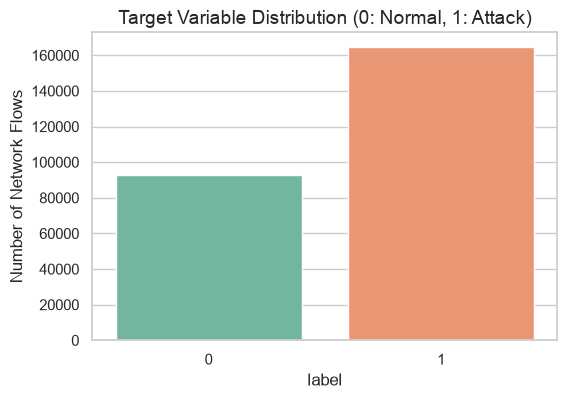

Analysis 1: Shows the baseline class distribution to identify if SMOTE or class weighting is needed.



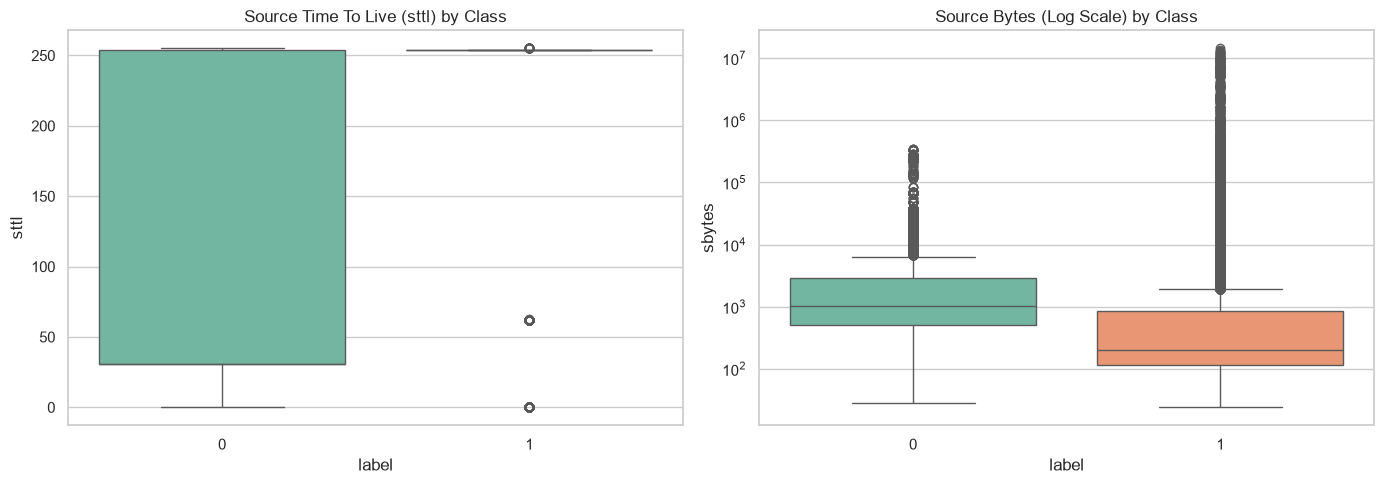

Analysis 2: Visually proves that Attack traffic has a distinctly different TTL and byte footprint than Normal traffic.



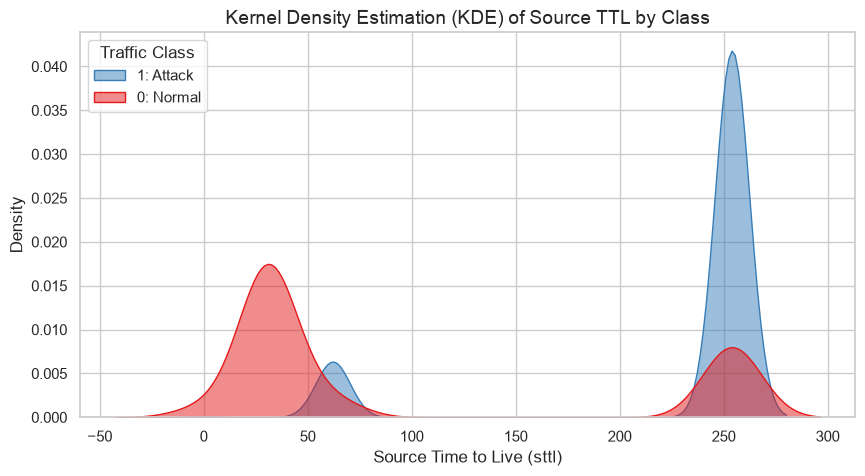

Analysis 3 (KDE): Normal traffic has a broader, varied distribution, while Attack traffic heavily clusters around specific TTL values generated by automated scripts.



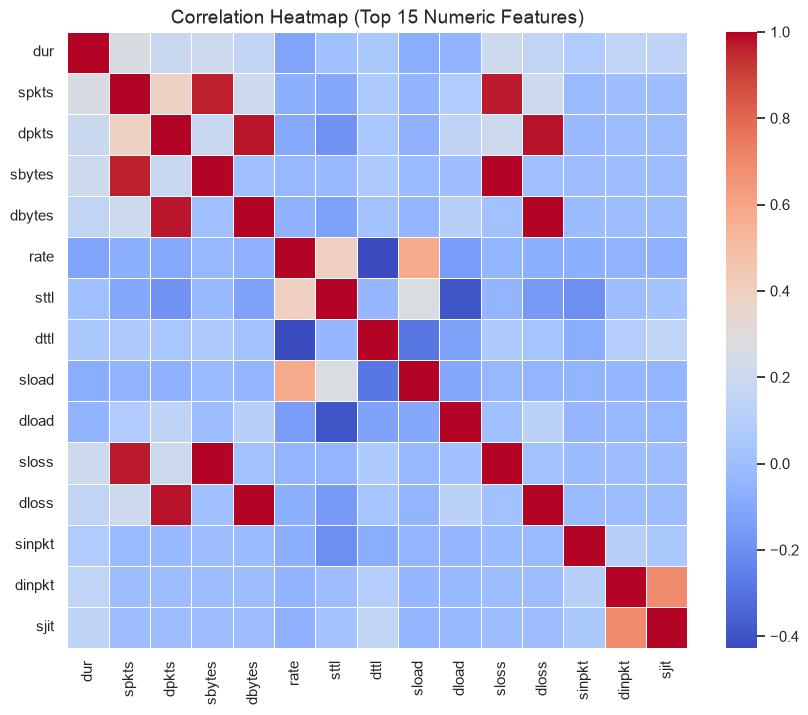

Analysis 4: Identifies highly correlated features (e.g., packets vs. bytes) justifying dimensionality reduction.



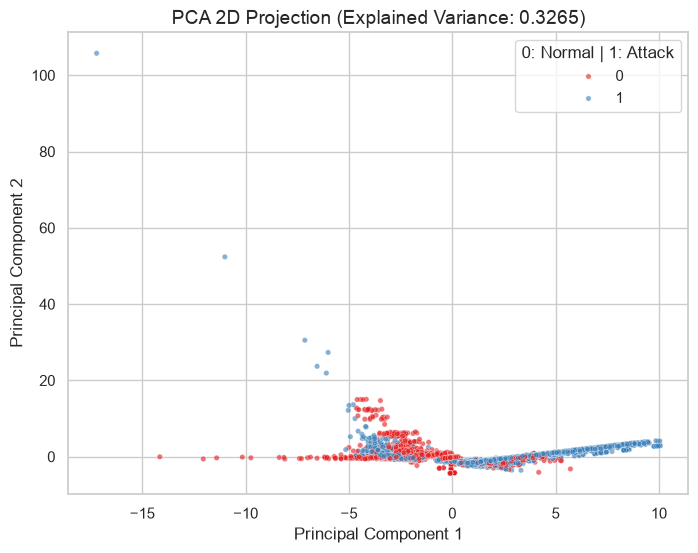

Analysis 5: The top 2 components capture 32.65% of the variance.
The heavy overlap in the scatter plot proves this dataset is highly complex and not linearly separable, justifying the use of non-linear models like LightGBM.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0}) 

# ==========================================
# 1. LOAD DATA
# ==========================================
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

# Combine temporarily for consistent preprocessing and EDA
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# ==========================================
# 2. DATA CLEANING
# ==========================================
df.drop('id', axis=1, inplace=True) # Drop ID to prevent leakage
df.replace('-', np.nan, inplace=True)
df.fillna('unknown', inplace=True)

# ==========================================
# 3. VISUAL EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("--- Starting Visual EDA ---")

# Plot 1: Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Target Variable Distribution (0: Normal, 1: Attack)', fontsize=14)
plt.ylabel('Number of Network Flows')
plt.show()
print("Analysis 1: Shows the baseline class distribution to identify if SMOTE or class weighting is needed.\n")

# Plot 2: Feature Distributions by Class (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='label', y='sttl', ax=axes[0], hue='label', palette='Set2', legend=False)
axes[0].set_title('Source Time To Live (sttl) by Class', fontsize=12)

sns.boxplot(data=df, x='label', y='sbytes', ax=axes[1], hue='label', palette='Set2', legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Source Bytes (Log Scale) by Class', fontsize=12)

plt.tight_layout()
plt.show()
print("Analysis 2: Visually proves that Attack traffic has a distinctly different TTL and byte footprint than Normal traffic.\n")

# Plot 3: Kernel Density Estimation (KDE)
plt.figure(figsize=(10, 5))
# We use a sample of 50,000 rows because KDE is computationally heavy on massive datasets
df_sample = df.sample(n=50000, random_state=42)

# common_norm=False ensures both curves are scaled independently to clearly see their distinct shapes
sns.kdeplot(data=df_sample, x='sttl', hue='label', fill=True, 
            palette='Set1', common_norm=False, alpha=0.5)

plt.title('Kernel Density Estimation (KDE) of Source TTL by Class', fontsize=14)
plt.xlabel('Source Time to Live (sttl)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Customizing the legend for clarity
plt.legend(title='Traffic Class', labels=['1: Attack', '0: Normal'])
plt.show()
print("Analysis 3 (KDE): Normal traffic has a broader, varied distribution, while Attack traffic heavily clusters around specific TTL values generated by automated scripts.\n")

# Plot 4: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.drop(columns=['label', 'attack_cat']).select_dtypes(include=[np.number]).columns[:15]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Top 15 Numeric Features)', fontsize=14)
plt.show()
print("Analysis 4: Identifies highly correlated features (e.g., packets vs. bytes) justifying dimensionality reduction.\n")

# ==========================================
# 4. PREPROCESSING & ENCODING
# ==========================================
X = df.drop(['label', 'attack_cat'], axis=1)
y = df['label']

categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Split back into train and test sets
X_train = X.iloc[:len(train_df)]
y_train = y.iloc[:len(train_df)]
X_test = X.iloc[len(train_df):]
y_test = y.iloc[len(train_df):]

# ==========================================
# 5. FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 6. DIMENSIONALITY REDUCTION (PCA VISUALIZATION)
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
explained_var = pca.explained_variance_ratio_.sum()

# Plot 5: PCA 2D Scatter Plot
plt.figure(figsize=(8, 6))
sample_idx = np.random.choice(X_pca.shape[0], 10000, replace=False)
sns.scatterplot(x=X_pca[sample_idx, 0], y=X_pca[sample_idx, 1], 
                hue=y_train.iloc[sample_idx], palette='Set1', alpha=0.6, s=15)

plt.title(f'PCA 2D Projection (Explained Variance: {explained_var:.4f})', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='0: Normal | 1: Attack')
plt.show()
print(f"Analysis 5: The top 2 components capture {explained_var*100:.2f}% of the variance.")
print("The heavy overlap in the scatter plot proves this dataset is highly complex and not linearly separable, justifying the use of non-linear models like LightGBM.")

In [2]:
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# 1. Baseline Model: Logistic Regression
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("--- Logistic Regression Baseline ---")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}\n")

# 2. Advanced Model: LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42, n_jobs=-1)
lgb_model.fit(X_train_scaled, y_train)
lgb_preds = lgb_model.predict(X_test_scaled)
lgb_probs = lgb_model.predict_proba(X_test_scaled)[:, 1]

print("--- LightGBM Model ---")
print(classification_report(y_test, lgb_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lgb_probs):.4f}")

# 3. Save Artifacts for Reproducibility
joblib.dump(lgb_model, 'models/unsw_lgbm.pkl')
joblib.dump(scaler, 'models/unsw_scaler.pkl')

--- Logistic Regression Baseline ---
              precision    recall  f1-score   support

           0       0.74      0.94      0.82     56000
           1       0.97      0.84      0.90    119341

    accuracy                           0.87    175341
   macro avg       0.85      0.89      0.86    175341
weighted avg       0.89      0.87      0.88    175341

ROC-AUC: 0.9689

[LightGBM] [Info] Number of positive: 45332, number of negative: 37000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5878
[LightGBM] [Info] Number of data points in the train set: 82332, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550600 -> initscore=0.203095
[LightGBM] [Info] Start training from score 0.203095
--- LightGBM Model ---
              precision    recall  f1-sc

['models/unsw_scaler.pkl']

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


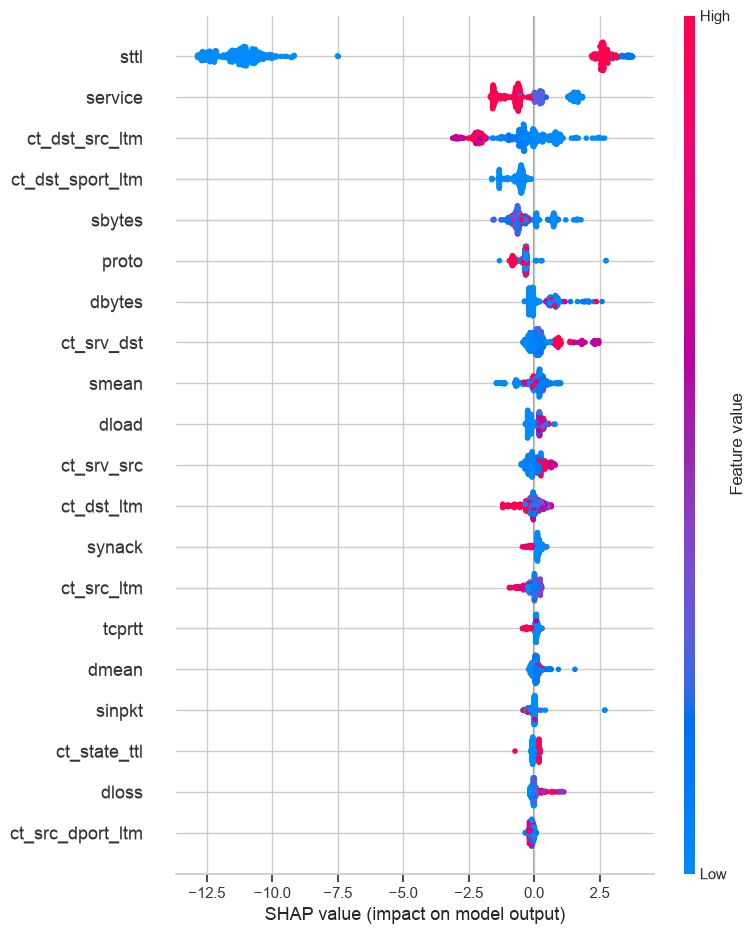


--- Fairness Audit: False Positive Rates ---
TCP Traffic FPR: 0.0174
UDP Traffic FPR: 0.0392
Disparate Impact Analysis: If one protocol has a drastically higher FPR, the model is biased and will block legitimate traffic for that protocol.


In [3]:
import shap
from sklearn.metrics import confusion_matrix

# 1. Feature Explainability (SHAP)
explainer = shap.TreeExplainer(lgb_model)
X_test_sample = X_test_scaled[:500] # Use a sample to save computation
shap_values = explainer.shap_values(X_test_sample)

# Plot feature importance (Pass original columns for readability)
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

# 2. Fairness Audit (Protocol Bias)
# Let's check the False Positive Rate (FPR) across different protocols
proto_col_idx = X.columns.get_loc('proto')
tcp_encoded = label_encoders['proto'].transform(['tcp'])[0]
udp_encoded = label_encoders['proto'].transform(['udp'])[0]

def calculate_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

# Filter predictions by protocol
tcp_mask = (X_test['proto'] == tcp_encoded)
udp_mask = (X_test['proto'] == udp_encoded)

tcp_fpr = calculate_fpr(y_test[tcp_mask], lgb_preds[tcp_mask])
udp_fpr = calculate_fpr(y_test[udp_mask], lgb_preds[udp_mask])

print("\n--- Fairness Audit: False Positive Rates ---")
print(f"TCP Traffic FPR: {tcp_fpr:.4f}")
print(f"UDP Traffic FPR: {udp_fpr:.4f}")
print("Disparate Impact Analysis: If one protocol has a drastically higher FPR, the model is biased and will block legitimate traffic for that protocol.")

In [10]:
#Retrieve Test Data to be used as payload in the API
X_test.iloc[100].to_dict()

{'dur': 33.787666,
 'proto': 113.0,
 'service': 4.0,
 'state': 4.0,
 'spkts': 14.0,
 'dpkts': 18.0,
 'sbytes': 1684.0,
 'dbytes': 10168.0,
 'rate': 0.917495,
 'sttl': 31.0,
 'dttl': 29.0,
 'sload': 370.312653,
 'dload': 2273.96582,
 'sloss': 3.0,
 'dloss': 5.0,
 'sinpkt': 2599.023615,
 'dinpkt': 1987.476647,
 'sjit': 225330.8814,
 'djit': 197173.1144,
 'swin': 255.0,
 'stcpb': 1009427149.0,
 'dtcpb': 3155920751.0,
 'dwin': 255.0,
 'tcprtt': 0.000695,
 'synack': 0.000555,
 'ackdat': 0.00014,
 'smean': 120.0,
 'dmean': 565.0,
 'trans_depth': 1.0,
 'response_body_len': 3924.0,
 'ct_srv_src': 3.0,
 'ct_state_ttl': 0.0,
 'ct_dst_ltm': 9.0,
 'ct_src_dport_ltm': 2.0,
 'ct_dst_sport_ltm': 1.0,
 'ct_dst_src_ltm': 2.0,
 'is_ftp_login': 0.0,
 'ct_ftp_cmd': 0.0,
 'ct_flw_http_mthd': 1.0,
 'ct_src_ltm': 4.0,
 'ct_srv_dst': 5.0,
 'is_sm_ips_ports': 0.0}